In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data=pd.read_csv(r"C:\Users\DELL\clustering\Mall_Customers.csv")
data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
data=data.drop(['CustomerID','Gender'],axis=1,inplace=True)

In [ ]:
data.head()

In [ ]:
#EDA
#Annual icome vs score using scatterplot
plt.figure(figsize =(6,5))
 
plt.scatter(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=data,
    color='black',
    alpha=0.9,
    linewidths=0.5,
    edgecolors= 'red',
    marker = 'o',
    s=40
)
 
plt.title("Annual income vs spending score")
plt.xlabel('Annual income')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [ ]:
#Feature engineering
#standardscaler
from sklearn.preprocessing import StandardScaler
#load the model
scaler=StandardScaler()
#fit model
scale_data=scaler.fit_transform(data)
scale_data

In [28]:
#convert sacled data array into dataframe
data=pd.DataFrame(scale_data,columns=data.columns)
data

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


In [61]:
#train the model
from sklearn.cluster import KMeans
#load the model
model=KMeans(n_clusters=5,random_state=42)
model.fit(data)
#display the label 
model.labels_

c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 4, 2, 4, 2, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 2, 4, 0, 4, 2, 4,
       0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 4, 0, 2,
       0, 4, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 1, 2, 2, 2, 0, 0, 0, 0, 2, 1, 3, 3, 1, 3, 1, 3, 0, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 0, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3,
       1, 3], dtype=int32)

In [62]:
data['Cluster']=model.labels_
data.head()

,Age,Annual Income (k$),Spending Score (1-100),cluster,Cluster
0,-1.424569,-1.738999,-0.434801,2,2
1,-1.281035,-1.738999,1.195704,2,4
2,-1.352802,-1.700830,-1.715913,2,2
3,-1.137502,-1.700830,1.040418,2,4
4,-0.563369,-1.662660,-0.395980,2,2


In [63]:
#value counts of cluster column
data['Cluster'].value_counts()

Cluster
0    65
3    40
1    38
2    35
4    22
Name: count, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_12736\1165277449.py:3: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


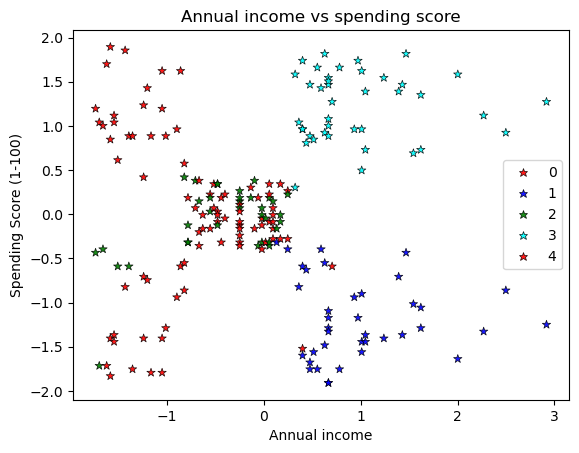

In [64]:
#display the cluster
colors=['red','blue','green','cyan']
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster', #if we remove this there will be no color difference between the clusters
    data=data,
    color='black',
    alpha=0.9,
    palette=colors,
    linewidths=0.5,
    edgecolors= 'black',
    marker = '*',
    s=40
)
 
plt.title("Annual income vs spending score")
plt.xlabel('Annual income')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12736\1820627671.py:3: UserWarning: 
The palette list has fewer values (4) than needed (64) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


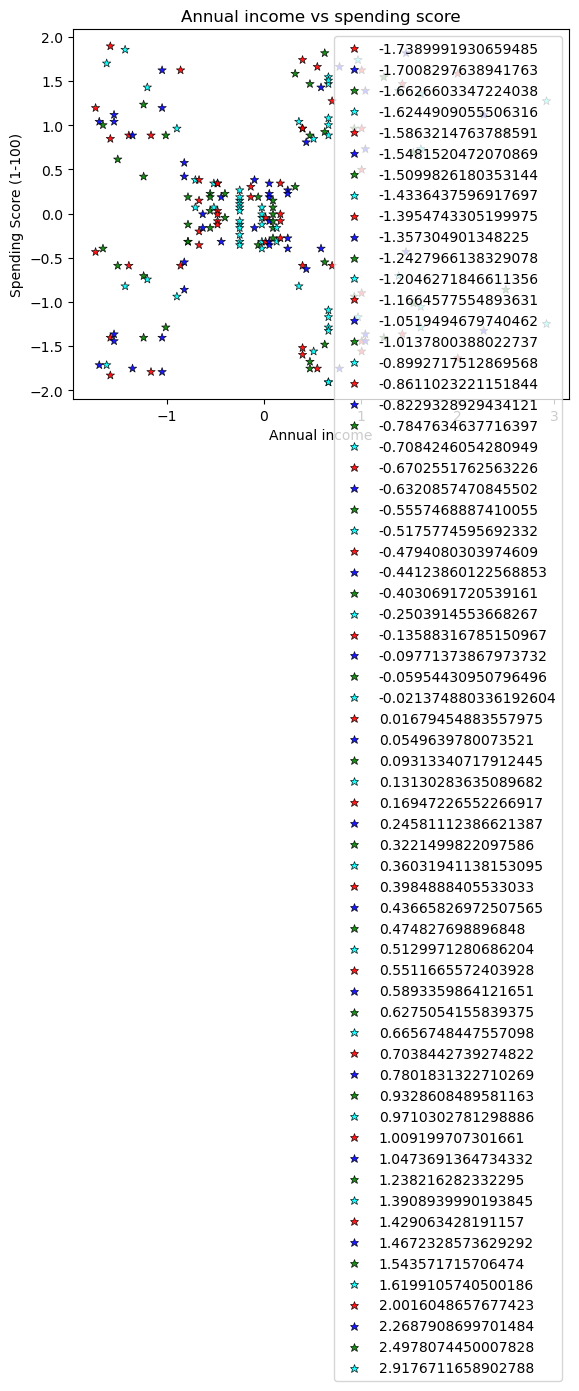

In [65]:
#for annual income 
colors=['red','blue','green','cyan']
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Annual Income (k$)', 
    data=data,
    color='black',
    alpha=0.9,
    palette=colors,
    linewidths=0.5,
    edgecolors= 'black',
    marker = '*',
    s=40
)
 
plt.title("Annual income vs spending score")
plt.xlabel('Annual income')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [75]:
x=data[['Annual Income (k$)'] ]
y=data['Cluster']

In [76]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [79]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.25


c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

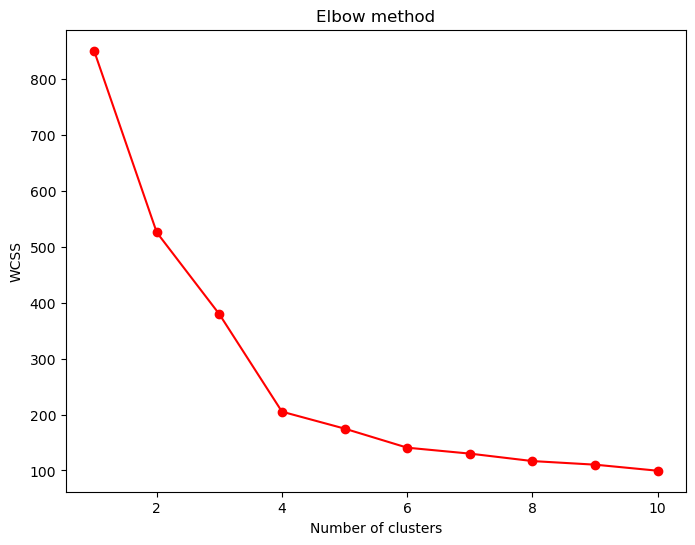

In [80]:
# Elbow Method
wcss=[]
for i in range(1,11):
    model=KMeans(n_clusters=i,random_state=42)
    model.fit(data.drop("Cluster",axis=1))
    wcss.append(model.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,11),wcss,marker='o',color='red')
plt.title("Elbow method") 
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()


In [81]:
#save the model
import joblib
joblib.dump(model,'kmeans_model.pkl')
data.to_csv('clustered_data.csv',index=False)
joblib.dump(model,'kmeans_model.pkl')


['kmeans_model.pkl']